### Timeit library

In [4]:
from timeit import timeit

def fib(n):
    return n if n < 2 else fib(n - 2) + fib(n - 1)


iterations = 100
total_time = timeit("fib(30)", number=iterations, globals=globals())

f"Average time is {total_time / iterations:.2f} seconds"

'Average time is 0.09 seconds'

In [3]:
def fib(n):
    return n if n < 2 else fib(n - 2) + fib(n - 1)
%timeit fib(30) 

91.9 ms ± 1.24 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [4]:
%%timeit
total = 0
for i in range(1000):
    total += i


28.7 µs ± 3.92 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### cProfile

In [4]:
from cProfile import Profile
from pstats import SortKey, Stats

def fib(n):
    return n if n < 2 else fib(n - 2) + fib(n - 1)


with Profile() as profile:
    print(f"{fib(35) = }")
    (
        Stats(profile)
        .strip_dirs()
        .sort_stats(SortKey.CALLS)
        .print_stats()
    )

fib(35) = 9227465
         29861415 function calls (702 primitive calls) in 5.554 seconds

   Ordered by: call count

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
29860702/0    5.552    0.000    0.000          4179259204.py:4(fib)
  146/142    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
       66    0.000    0.000    0.000    0.000 enum.py:1544(_get_value)
       29    0.000    0.000    0.000    0.000 enum.py:1129(__new__)
       29    0.000    0.000    0.000    0.000 enum.py:726(__call__)
       24    0.000    0.000    0.000    0.000 typing.py:2182(cast)
       23    0.000    0.000    0.000    0.000 {built-in method builtins.len}
       15    0.000    0.000    0.000    0.000 socket.py:621(send)
       15    0.000    0.000    0.000    0.000 enum.py:1551(__or__)
       11    0.000    0.000    0.000    0.000 {built-in method builtins.hasattr}
       10    0.000    0.000    0.000    0.000 inspect.py:2804(kind)
        8    0.000    0.0

### Pyinstrument

In [2]:
from random import uniform
from random import random

def estimate_pi(n):
    return 4 * sum(hits(point()) for _ in range(n)) / n


def hits(point):
    return abs(point) <= 1


def point():
    return complex(uniform(0, 1), uniform(0, 1))
    # return complex(random(), random())

n = 10_000_000
pi_approx = estimate_pi(n)
print(f"{n = :<10,} {pi_approx = :.6f}")

n = 10,000,000 pi_approx = 3.141611


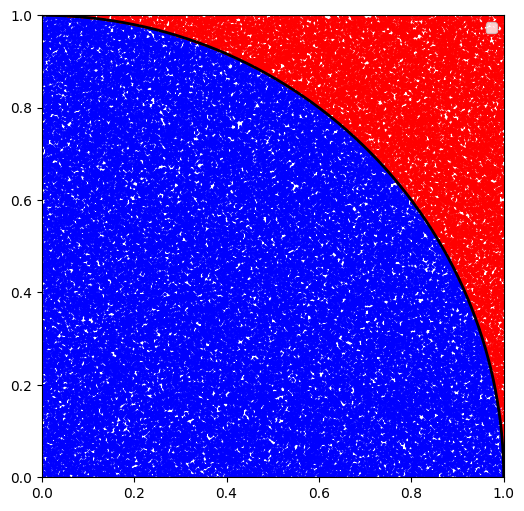

Estimated pi after 100,000 samples: 3.142280


In [3]:
# Live plotting while running estimate_pi: points appear as they're sampled
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np

def estimate_pi_live(n, update_every=2000):
    inside = 0
    xs_in, ys_in = [], []
    xs_out, ys_out = [], []

    fig, ax = plt.subplots(figsize=(6,6))
    sc_in = ax.scatter([], [], s=1, color='blue')
    sc_out = ax.scatter([], [], s=1, color='red')
    theta = np.linspace(0, np.pi/2, 400)
    ax.plot(np.cos(theta), np.sin(theta), color='black', linewidth=2)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_aspect('equal','box')
    ax.legend()
    display(fig)
    plt.show(block=False)

    for i in range(1, n+1):
        z = point()
        x, y = z.real, z.imag
        if hits(z):
            inside += 1
            xs_in.append(x); ys_in.append(y)
        else:
            xs_out.append(x); ys_out.append(y)

        if i % update_every == 0 or i == n:
            sc_in.set_offsets(np.column_stack((xs_in, ys_in)))
            sc_out.set_offsets(np.column_stack((xs_out, ys_out)))
            clear_output(wait=True)
            display(fig)
            plt.pause(0.001)

    return 4 * inside / n

n = 100_000
pi_est = estimate_pi_live(n, update_every=2000)
print(f'Estimated pi after {n:,} samples: {pi_est:.6f}')


$$point\_ratio = n\_inside / n = area\_ratio$$
$$area\_ratio = circular\_area / square\_area = 1/4 * pi * r^2 / l^2$$
$$pi = 4 *n\_inside / n$$



In [ ]:
from pyinstrument import Profiler

interval=0.1
print(f"take snapshots every {interval} second")
with Profiler(interval=interval) as profiler:
    estimate_pi(n=10_000_000)


profiler.print()

# profiler.open_in_browser()

take snapshots every 0.1 second

  _     ._   __/__   _ _  _  _ _/_   Recorded: 12:46:40  Samples:  192
 /_//_/// /_\ / //_// / //_'/ //     Duration: 19.393    CPU time: 19.347
/   _/                      v5.1.2

Profile at /home/lykhin/ipykernel_1767279/3294399892.py:5

19.4 <module>  /home/lykhin/ipykernel_1767279/3294399892.py:1
└─ 19.4 estimate_pi  /home/lykhin/ipykernel_1767279/1875491207.py:4
   ├─ 18.8 <genexpr>  /home/lykhin/ipykernel_1767279/1875491207.py:5
   │  ├─ 12.4 point  /home/lykhin/ipykernel_1767279/1875491207.py:12
   │  │  ├─ 6.8 Random.uniform  random.py:494
   │  │  │  ├─ 4.6 [self]  random.py
   │  │  │  └─ 2.1 Random.random  <built-in>
   │  │  └─ 5.7 [self]  /home/lykhin/ipykernel_1767279/1875491207.py
   │  ├─ 4.0 [self]  /home/lykhin/ipykernel_1767279/1875491207.py
   │  └─ 2.3 hits  /home/lykhin/ipykernel_1767279/1875491207.py:8
   │     ├─ 1.7 [self]  /home/lykhin/ipykernel_1767279/1875491207.py
   │     └─ 0.6 abs  <built-in>
   └─ 0.6 [self]  /home/lykhi

'/home/lykhin/tmpopnhcp5u.html'